In [27]:
# BLOQUE 1: Imports y setup
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Optimización
try:
    import pulp as pl
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pulp"])
    import pulp as pl

# Gráficos (opcional)
import matplotlib.pyplot as plt

## 1. Carga de datos

In [29]:
# BLOQUE 2: Carga de datos
BASE = Path('.')  # ajusta si los archivos están en otra carpeta

ventas = pd.read_csv(BASE / 'ventas.csv', parse_dates=['fecha'])
productos = pd.read_csv(BASE / 'productos.csv')
inventario = pd.read_csv(BASE / 'inventario.csv', parse_dates=['fecha_ultima_reposicion'])
costos = pd.read_csv(BASE / 'Costos_Logisticos.csv')

display(ventas.head(2))
display(productos.head(2))
display(inventario.head(2))
display(costos.head(5))

,fecha,tienda,sku,cantidad_vendida,precio_venta_unitario,descuento_aplicado,venta_neta
0,2023-01-01,TIENDA001,HM000088,1,28.24,0.2,22.592
1,2023-01-01,TIENDA001,HM000096,1,64.60,0.1,58.140


,sku,categoria,subcategoria,talla,color,costo_unitario,precio_venta,proveedor_id,lead_time_dias,cantidad_minima_pedido,multiplico_pedido,temporada,margen
0,HM000001,Vestidos,Temporada,XL,Negro,10.35,17.75,PROV001,18,50,10,Invierno,7.40
1,HM000002,Camisetas,Temporada,L,Rojo,34.60,40.98,PROV002,12,50,10,Verano,6.38


,tienda,sku,stock_actual,stock_seguridad_actual,stock_en_transito,fecha_ultima_reposicion
0,TIENDA001,HM000084,18,16,16,2024-01-06
1,TIENDA001,HM000054,54,23,20,2023-12-30


,Escenario,costo_pedido,costo_mantenimiento_anual,costo_almacenamiento_m2,costo_transferencia_tienda,costo_rotura_stock,costo_obsolescencia
0,Escenario 1,10.0,0.15,80.0,3.0,0.20,0.09
1,Escenario 2,40.0,0.20,100.0,4.0,0.25,0.12
2,Escenario 3,50.0,0.25,120.0,5.0,0.30,0.15
3,Escenario 4,55.0,0.30,130.0,6.0,0.35,0.18
4,Escenario 5,60.0,0.35,140.0,7.0,0.38,0.20


## 2. Preparación de parámetros y periodos

In [30]:
# ===== Parámetros editables =====
AGRUPAR_POR_TIENDA = True          # ← activar por tienda+SKU
PERIODICIDAD = 'M'                  # 'M' mensual, 'W' semanal
INCLUIR_TRANSITO_EN_INV0 = False    # True: inv0 = stock_actual + stock_en_transito

# --- Ventas (demanda por periodo) ---
ventas_2023 = ventas[(ventas['fecha'] >= '2023-01-01') & (ventas['fecha'] <= '2023-12-31')].copy()
ventas_2023['periodo'] = ventas_2023['fecha'].dt.to_period('M') if PERIODICIDAD=='M' else ventas_2023['fecha'].dt.to_period('W')

if AGRUPAR_POR_TIENDA:
    demanda = ventas_2023.groupby(['tienda','sku','periodo'], as_index=False)['cantidad_vendida'].sum()
else:
    demanda = ventas_2023.groupby(['sku','periodo'], as_index=False)['cantidad_vendida'].sum()

# Eje temporal (como strings tipo 'YYYY-MM')
periodos = sorted(demanda['periodo'].unique().tolist(), key=lambda x: str(x))
periodos = [str(p) for p in periodos]

# --- Productos (costos y lead time) ---
prod = productos.copy()
# pasar lead time días → meses (ceil)
prod['lead_time_meses'] = np.ceil(prod.get('lead_time_dias', 0)/30.0).fillna(0).astype(int)

# --- Inventario inicial ---
if AGRUPAR_POR_TIENDA:
    inv0_df = inventario.groupby(['tienda','sku'], as_index=False)[['stock_actual','stock_en_transito']].sum()
else:
    inv0_df = inventario.groupby(['sku'], as_index=False)[['stock_actual','stock_en_transito']].sum()

inv0_df['inv0'] = (inv0_df['stock_actual'] + inv0_df['stock_en_transito']) if INCLUIR_TRANSITO_EN_INV0 \
                   else inv0_df['stock_actual']

# --- Universo de claves (todas las combinaciones presentes) ---
if AGRUPAR_POR_TIENDA:
    claves = pd.concat([demanda[['tienda','sku']].drop_duplicates(),
                        inv0_df[['tienda','sku']].drop_duplicates()]).drop_duplicates()
else:
    claves = pd.concat([demanda[['sku']].drop_duplicates(),
                        inv0_df[['sku']].drop_duplicates()]).drop_duplicates()

# --- Mapas de parámetros (independientes del escenario) ---
if AGRUPAR_POR_TIENDA:
    demanda_map = {(r['tienda'], r['sku'], str(r['periodo'])): float(r['cantidad_vendida'])
                   for _, r in demanda.iterrows()}
else:
    demanda_map = {(r['sku'], str(r['periodo'])): float(r['cantidad_vendida'])
                   for _, r in demanda.iterrows()}

costo_compra     = {r['sku']: float(r.get('costo_unitario', 0)) for _, r in prod.iterrows()}
precio_venta     = {r['sku']: float(r.get('precio_venta', 0))   for _, r in prod.iterrows()}
lead_time_meses  = {r['sku']: int(r.get('lead_time_meses', 0))  for _, r in prod.iterrows()}

if AGRUPAR_POR_TIENDA:
    inv0_map = {(r['tienda'], r['sku']): float(r['inv0']) for _, r in inv0_df.iterrows()}
else:
    inv0_map = {r['sku']: float(r['inv0']) for _, r in inv0_df.iterrows()}

len(claves), len(periodos)


(1000, 12)

## 3. Función para construir, resolver y exportar un escenario

In [31]:
# Función para construir, resolver y exportar un escenario
import re, time

def correr_escenario(nombre_escenario: str):
    # --- parámetros del escenario (costos logísticos) ---
    row_c = costos.loc[costos['Escenario'] == nombre_escenario].iloc[0]
    costo_mantenimiento_anual = float(row_c['costo_mantenimiento_anual'])
    costo_rotura_stock        = float(row_c['costo_rotura_stock'])
    if PERIODICIDAD == 'M':
        holding_factor = costo_mantenimiento_anual/12.0
    elif PERIODICIDAD == 'W':
        holding_factor = costo_mantenimiento_anual/52.0
    else:
        holding_factor = costo_mantenimiento_anual

    # --- conjuntos ---
    if AGRUPAR_POR_TIENDA:
        CLAVES = [(r['tienda'], r['sku']) for _, r in claves.iterrows()]
    else:
        CLAVES = [(r['sku'],) for _, r in claves.iterrows()]
    T = periodos
    periodo_index = {t:i for i,t in enumerate(T)}

    # --- modelo ---
    modelo = pl.LpProblem(f'Plan_Reabastecimiento_MultiPeriodo__{nombre_escenario}', pl.LpMinimize)

    # variables (no negativas)
    Q, I, B = {}, {}, {}
    for k in CLAVES:
        for t in T:
            Q[k,t] = pl.LpVariable(f"Q_{'_'.join(map(str,k))}_{t}", lowBound=0)
            I[k,t] = pl.LpVariable(f"I_{'_'.join(map(str,k))}_{t}", lowBound=0)
            B[k,t] = pl.LpVariable(f"B_{'_'.join(map(str,k))}_{t}", lowBound=0)

    # objetivo: compra + mantenimiento + ruptura
    obj = []
    for k in CLAVES:
        sku = k[-1]
        for t in T:
            obj.append(costo_compra.get(sku,0) * Q[k,t])
            obj.append(holding_factor * costo_compra.get(sku,0) * I[k,t])
            obj.append(costo_rotura_stock * precio_venta.get(sku,0) * B[k,t])
    modelo += pl.lpSum(obj)

    # helper demanda
    def demanda_t(k, t):
        if AGRUPAR_POR_TIENDA:
            tienda, sku = k
            return demanda_map.get((tienda, sku, t), 0.0)
        else:
            (sku,) = k
            return demanda_map.get((sku, t), 0.0)

    # balance: I_t = I_{t-1} - B_{t-1} + llegadas - D_t + B_t
    for k in CLAVES:
        sku = k[-1]
        L = max(0, lead_time_meses.get(sku, 0))
        for t in T:
            i = periodo_index[t]
            # llegadas por lead time
            if L == 0:
                llegadas = Q[k, t]
            else:
                llegadas = Q[k, T[i-L]] if i - L >= 0 else 0

            # inventario/backorder previos
            if i == 0:
                inv_prev  = inv0_map.get(k if AGRUPAR_POR_TIENDA else k[-1], 0.0)
                back_prev = 0.0
            else:
                inv_prev  = I[k, T[i-1]]
                back_prev = B[k, T[i-1]]

            dem = demanda_t(k, t)
            modelo += I[k, t] == (inv_prev - back_prev + llegadas - dem + B[k, t])

    # resolver
    status = modelo.solve(pl.PULP_CBC_CMD(msg=False))
    estado = pl.LpStatus[modelo.status]
    costo_total = pl.value(modelo.objective)

    # extraer resultados
    rows_Q, rows_I, rows_B = [], [], []
    dem_total = 0.0
    for k in CLAVES:
        for t in T:
            rows_Q.append((*k, t, Q[k,t].value()))
            rows_I.append((*k, t, I[k,t].value()))
            rows_B.append((*k, t, B[k,t].value()))
            dem_total += demanda_t(k, t)

    # dataframes con/sin tienda
    if AGRUPAR_POR_TIENDA:
        df_Q = pd.DataFrame(rows_Q, columns=['tienda','sku','periodo','Q'])
        df_I = pd.DataFrame(rows_I, columns=['tienda','sku','periodo','I'])
        df_B = pd.DataFrame(rows_B, columns=['tienda','sku','periodo','B'])
    else:
        df_Q = pd.DataFrame(rows_Q, columns=['sku','periodo','Q'])
        df_I = pd.DataFrame(rows_I, columns=['sku','periodo','I'])
        df_B = pd.DataFrame(rows_B, columns=['sku','periodo','B'])

    # KPIs
    back_total = float(df_B['B'].fillna(0).sum())
    nivel_servicio = None if dem_total == 0 else (1 - back_total/dem_total)

    # export por escenario (sufijo)
    slug = re.sub(r'[^0-9A-Za-z_-]+','_', nombre_escenario)
    df_Q.to_csv(f'plan_pedidos_optimo__{slug}.csv', index=False)
    df_I.to_csv(f'inventario_proyectado__{slug}.csv', index=False)
    df_B.to_csv(f'backorders_proyectados__{slug}.csv', index=False)

    # resumen por escenario
    pd.DataFrame({
        'escenario':[nombre_escenario],
        'estado':[estado],
        'costo_total':[costo_total],
        'nivel_servicio':[nivel_servicio],
        'backorders_totales':[back_total],
        'demanda_total':[dem_total],
        'agrupado_por_tienda':[AGRUPAR_POR_TIENDA],
        'periodicidad':[PERIODICIDAD],
        'holding_factor':[holding_factor],
        'costo_rotura_stock':[costo_rotura_stock],
        'timestamp':[time.strftime("%Y-%m-%d %H:%M:%S")]
    }).to_csv(f'resumen_modelo__{slug}.csv', index=False)

    return {
        'escenario': nombre_escenario,
        'estado': estado,
        'costo_total': costo_total,
        'nivel_servicio': nivel_servicio,
        'backorders_totales': back_total,
        'demanda_total': dem_total
    }


## 4. Ejecutar escenarios y consolidar

In [32]:
escenarios = costos['Escenario'].dropna().unique().tolist()[:5]

resumen_todos = []
for esc in escenarios:
    print(f"Resolviendo {esc} ...")
    info = correr_escenario(esc)
    resumen_todos.append(info)

resumen_escenarios = pd.DataFrame(resumen_todos)
display(resumen_escenarios)

# guardar consolidado (para el dashboard)
resumen_escenarios.to_csv('resumen_escenarios.csv', index=False)
print("Exportado: resumen_escenarios.csv")


Resolviendo Escenario 1 ...
Resolviendo Escenario 2 ...
Resolviendo Escenario 3 ...
Resolviendo Escenario 4 ...
Resolviendo Escenario 5 ...


,escenario,estado,costo_total,nivel_servicio,backorders_totales,demanda_total
0,Escenario 1,Optimal,3.863243e+07,0.208350,1194673.0,1509092.0
1,Escenario 2,Optimal,4.036561e+07,0.445392,836955.0,1509092.0
2,Escenario 3,Optimal,4.163562e+07,0.601364,601579.0,1509092.0
3,Escenario 4,Optimal,4.262214e+07,0.687054,472264.0,1509092.0
4,Escenario 5,Optimal,4.313057e+07,0.727767,410824.0,1509092.0


Exportado: resumen_escenarios.csv


## 5. Restricciones de balance

In [23]:
# I_t = I_{t-1} - B_{t-1} + llegadas_t - D_t + B_t
def demanda_t(k, t):
    if AGRUPAR_POR_TIENDA:
        tienda, sku = k
        return demanda_map.get((tienda, sku, t), 0.0)
    else:
        (sku,) = k
        return demanda_map.get((sku, t), 0.0)

for k in CLAVES:
    sku = k[-1]
    L = max(0, lead_time_meses.get(sku, 0))
    for t in T:
        i = periodo_index[t]
        # Llegadas por lead time
        if L == 0:
            llegadas = Q[k, t]
        else:
            llegadas = Q[k, T[i-L]] if i - L >= 0 else 0

        # Inventario/Backorder del periodo anterior
        if i == 0:
            inv_prev  = inv0_map.get(k if AGRUPAR_POR_TIENDA else k[-1], 0.0)
            back_prev = 0.0
        else:
            inv_prev  = I[k, T[i-1]]
            back_prev = B[k, T[i-1]]

        dem = demanda_t(k, t)

        # Balance CORRECTO
        modelo += I[k, t] == (inv_prev - back_prev + llegadas - dem + B[k, t])


## 6. Resolver y exportar resultados

In [24]:
import re, time

def correr_escenario(nombre_escenario):
    # --- parámetros del escenario ---
    row_c = costos.loc[costos['Escenario'] == nombre_escenario].iloc[0]
    costo_mantenimiento_anual = float(row_c['costo_mantenimiento_anual'])
    costo_rotura_stock = float(row_c['costo_rotura_stock'])
    if PERIODICIDAD == 'M':
        holding_factor = costo_mantenimiento_anual/12.0
    elif PERIODICIDAD == 'W':
        holding_factor = costo_mantenimiento_anual/52.0
    else:
        holding_factor = costo_mantenimiento_anual

    # --- conjuntos ---
    if AGRUPAR_POR_TIENDA:
        CLAVES = [(r['tienda'], r['sku']) for _, r in claves.iterrows()]
    else:
        CLAVES = [(r['sku'],) for _, r in claves.iterrows()]
    T = periodos
    periodo_index = {t:i for i,t in enumerate(T)}

    # --- modelo ---
    modelo = pl.LpProblem(f'Plan_Reabastecimiento_MultiPeriodo__{nombre_escenario}', pl.LpMinimize)

    # variables
    Q, I, B = {}, {}, {}
    for k in CLAVES:
        for t in T:
            Q[k,t] = pl.LpVariable(f"Q_{'_'.join(k)}_{t}", lowBound=0)
            I[k,t] = pl.LpVariable(f"I_{'_'.join(k)}_{t}", lowBound=0)
            B[k,t] = pl.LpVariable(f"B_{'_'.join(k)}_{t}", lowBound=0)

    # objetivo
    obj = []
    for k in CLAVES:
        sku = k[-1]
        for t in T:
            obj.append(costo_compra.get(sku,0) * Q[k,t])
            obj.append(holding_factor * costo_compra.get(sku,0) * I[k,t])
            obj.append(costo_rotura_stock * precio_venta.get(sku,0) * B[k,t])
    modelo += pl.lpSum(obj)

    # demanda helper
    def demanda_t(k, t):
        if AGRUPAR_POR_TIENDA:
            tienda, sku = k
            return demanda_map.get((tienda, sku, t), 0.0)
        else:
            (sku,) = k
            return demanda_map.get((sku, t), 0.0)

    # balance CORREGIDO: I_t = I_{t-1} - B_{t-1} + llegadas - D_t + B_t
    for k in CLAVES:
        sku = k[-1]
        L = max(0, lead_time_meses.get(sku, 0))
        for t in T:
            i = periodo_index[t]
            if L == 0:
                llegadas = Q[k, t]
            else:
                llegadas = Q[k, T[i-L]] if i - L >= 0 else 0

            if i == 0:
                inv_prev  = inv0_map.get(k if AGRUPAR_POR_TIENDA else k[-1], 0.0)
                back_prev = 0.0
            else:
                inv_prev  = I[k, T[i-1]]
                back_prev = B[k, T[i-1]]

            dem = demanda_t(k, t)
            modelo += I[k, t] == (inv_prev - back_prev + llegadas - dem + B[k, t])

    # resolver
    status = modelo.solve(pl.PULP_CBC_CMD(msg=False))
    estado = pl.LpStatus[modelo.status]
    costo_total = pl.value(modelo.objective)

    # extraer resultados
    rows_Q, rows_I, rows_B = [], [], []
    dem_total = 0.0
    for k in CLAVES:
        for t in T:
            rows_Q.append((*k, t, Q[k,t].value()))
            rows_I.append((*k, t, I[k,t].value()))
            rows_B.append((*k, t, B[k,t].value()))
            # acumular demanda para KPI de servicio
            dem_total += demanda_t(k, t)

    # dataframes
    if AGRUPAR_POR_TIENDA:
        df_Q = pd.DataFrame(rows_Q, columns=['tienda','sku','periodo','Q'])
        df_I = pd.DataFrame(rows_I, columns=['tienda','sku','periodo','I'])
        df_B = pd.DataFrame(rows_B, columns=['tienda','sku','periodo','B'])
    else:
        df_Q = pd.DataFrame(rows_Q, columns=['sku','periodo','Q'])
        df_I = pd.DataFrame(rows_I, columns=['sku','periodo','I'])
        df_B = pd.DataFrame(rows_B, columns=['sku','periodo','B'])

    # KPI servicio
    back_total = float(df_B['B'].fillna(0).sum())
    nivel_servicio = None if dem_total == 0 else (1 - back_total/dem_total)

    # export con sufijo del escenario
    slug = re.sub(r'[^0-9A-Za-z_-]+','_', nombre_escenario)
    df_Q.to_csv(f'plan_pedidos_optimo__{slug}.csv', index=False)
    df_I.to_csv(f'inventario_proyectado__{slug}.csv', index=False)
    df_B.to_csv(f'backorders_proyectados__{slug}.csv', index=False)

    pd.DataFrame({
        'escenario':[nombre_escenario],
        'costo_total':[costo_total],
        'nivel_servicio':[nivel_servicio],
        'backorders_totales':[back_total],
        'demanda_total':[dem_total],
        'agrupado_por_tienda':[AGRUPAR_POR_TIENDA],
        'periodicidad':[PERIODICIDAD],
        'holding_factor':[holding_factor],
        'costo_rotura_stock':[costo_rotura_stock],
        'timestamp':[time.strftime("%Y-%m-%d %H:%M:%S")]
    }).to_csv(f'resumen_modelo__{slug}.csv', index=False)

    return {
        'escenario': nombre_escenario,
        'estado': estado,
        'costo_total': costo_total,
        'nivel_servicio': nivel_servicio,
        'backorders_totales': back_total,
        'demanda_total': dem_total
    }



## 7. Ejecución de los 5 escenarios

In [25]:
escenarios = costos['Escenario'].dropna().unique().tolist()[:5]

resumen_todos = []
for esc in escenarios:
    print(f"Resolviendo {esc} ...")
    info = correr_escenario(esc)
    resumen_todos.append(info)

resumen_escenarios = pd.DataFrame(resumen_todos)
display(resumen_escenarios)

# Guardar resumen consolidado para el dashboard
resumen_escenarios.to_csv('resumen_escenarios.csv', index=False)
print("Exportado: resumen_escenarios.csv")


Resolviendo Escenario 1 ...
Resolviendo Escenario 2 ...
Resolviendo Escenario 3 ...
Resolviendo Escenario 4 ...
Resolviendo Escenario 5 ...


,escenario,estado,costo_total,nivel_servicio,backorders_totales,demanda_total
0,Escenario 1,Optimal,3.863243e+07,0.208350,1194673.0,1509092.0
1,Escenario 2,Optimal,4.036561e+07,0.445392,836955.0,1509092.0
2,Escenario 3,Optimal,4.163562e+07,0.601364,601579.0,1509092.0
3,Escenario 4,Optimal,4.262214e+07,0.687054,472264.0,1509092.0
4,Escenario 5,Optimal,4.313057e+07,0.727767,410824.0,1509092.0


Exportado: resumen_escenarios.csv


## 8. Visualizaciones

In [26]:
if AGRUPAR_POR_TIENDA:
    ejemplo = df_Q.groupby(['tienda','sku'])['Q'].sum().sort_values(ascending=False).head(1).index[0]
    t, s = ejemplo
    mask = (df_Q['tienda']==t) & (df_Q['sku']==s)
else:
    ejemplo = df_Q.groupby(['sku'])['Q'].sum().sort_values(ascending=False).head(1).index[0]
    s = ejemplo
    mask = (df_Q['sku']==s)

serie_Q = df_Q[mask].set_index('periodo')['Q'].astype(float).sort_index()
serie_I = df_I[mask].set_index('periodo')['I'].astype(float).sort_index()
serie_B = df_B[mask].set_index('periodo')['B'].astype(float).sort_index()

plt.figure()
serie_Q.plot(marker='o', title=f"Plan de pedidos óptimo - SKU {s}")
plt.xlabel('Periodo'); plt.ylabel('Unidades'); plt.show()

plt.figure()
serie_I.plot(marker='o', title=f"Inventario proyectado - SKU {s}")
plt.xlabel('Periodo'); plt.ylabel('Unidades'); plt.show()

plt.figure()
serie_B.plot(marker='o', title=f"Backorders proyectados - SKU {s}")
plt.xlabel('Periodo'); plt.ylabel('Unidades'); plt.show()


KeyError: 'tienda'

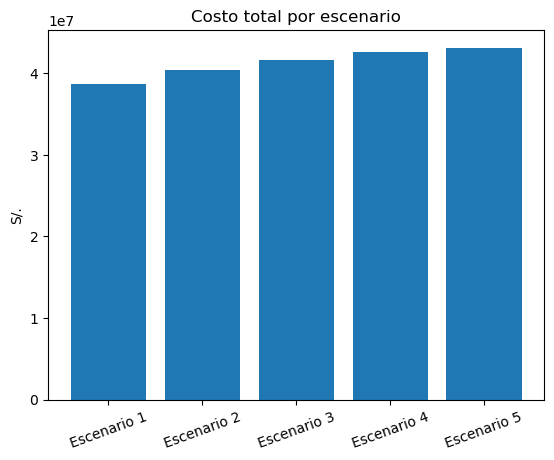

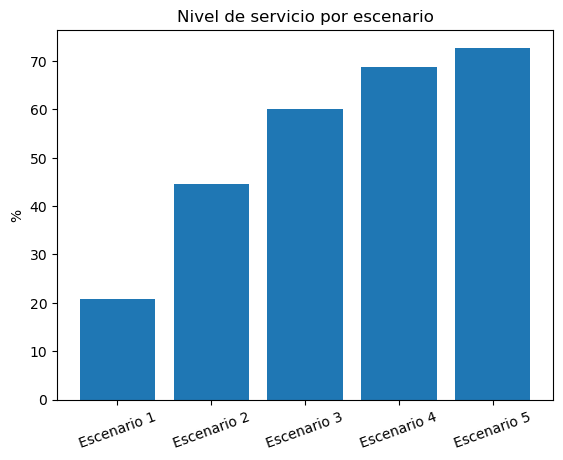

In [19]:
# BLOQUE 9: Barras comparativas
plt.figure()
plt.bar(resumen_escenarios['escenario'], resumen_escenarios['costo_total'])
plt.title('Costo total por escenario')
plt.xticks(rotation=20)
plt.ylabel('S/.')
plt.show()

plt.figure()
niv = resumen_escenarios['nivel_servicio'].fillna(0)*100
plt.bar(resumen_escenarios['escenario'], niv)
plt.title('Nivel de servicio por escenario')
plt.xticks(rotation=20)
plt.ylabel('%')
plt.show()
